In [39]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
rng = np.random.default_rng()

# Co to są przedziały ufności i dlaczego są ważne

## Scenariusz

Wyobraź sobie, że prowadzisz badanie, w którym chcesz sprawdzić, czy dzieci urodzone przez kobiety, które korzystały w ciąży z papierosów elektronicznych ważą mniej, niż noworodki w ogólnej populacji. 

*Uwaga: należałoby założyć, że waga urodzeniowa dziewczynek i chłopców nieco się różnią. Dane w omawianym przykładzie nie są prawdziwe, mają jedynie walor ilustracyjny!*

Załóżmy, że wiemy, że waga urodzeniowa noworodków w ogólnej populacji ma rozkład normalny o średniej 3.2 kg i odchyleniu standardowym 0.5 kg. Rozkład wygląda tak:

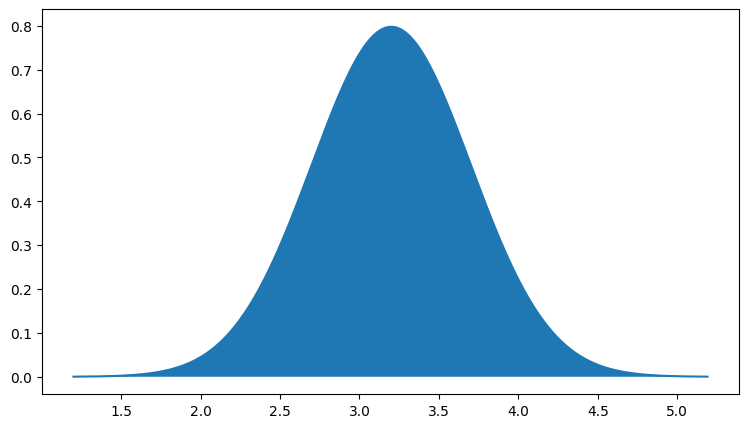

In [11]:
sd = 0.5
mean = 3.2

x = np.arange(1.2, 5.2, 0.01)
y = norm.pdf(x, loc=mean, scale=sd)
fix, ax = plt.subplots(figsize=(9, 5))
ax.plot(x,y)
ax.fill_between(x, y)
plt.show()

Jeżeli chcesz sprawdzić, jak zmienia się kształ rozkładu normalnego, gdy zmieniają się średnia (mean) i odchylenie standardowe (sd), użyj suwaków poniżej.

In [26]:
@interact(mean=(1.0,5.0), sd=(0.1,1.0))
def norm_plot(mean=3.2, sd=0.5):
    x = np.arange(1, 6, 0.01)
    y = norm.pdf(x, loc=mean, scale=sd)
    fix, ax = plt.subplots(figsize=(9, 5))
    ax.plot(x,y)
    ax.fill_between(x, y)
    ax.set_xlim((1, 6))
    ax.set_ylim((0, 1.5))
    plt.show()

interactive(children=(FloatSlider(value=3.2, description='mean', max=5.0, min=1.0), FloatSlider(value=0.5, des…

## Symulujemy badania!

Kiedy prowadzimy badania, nie znamy parametrów rozkładu w populacji - badania prowadzimy właśnie po to, by je poznać. Na potrzeby niniejszej prezentacji Statystyczny Potwór Spaghetti, który zna parametry wszystkich rozkładów we Wszechświecie wyjawił mi jednak, jakie są parametry rozkładu wagi urodzeniowej dzieci matek, które w ciąży używały elektronicznych papierosów. Dzięki temu możemy zasymulować losowanie próby 100 noworodków. Wielokrotnie!

Wciśnij przycisk "losuj", aby wylosować próbę 100 noworotków i przedstawić rozkład ich wagi na histogramie.

In [52]:
from IPython.display import display, clear_output

button = widgets.Button(
    value=False,
    description='Click me',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Description',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)

output = widgets.Output()
display(button, output)

def sample_and_plot(b, rng=rng):
    sample = rng.normal(loc=3.0, scale=0.5, size=100)
    clear_output(wait=False)
    with output:
        fig, ax = plt.subplots()
        ax.hist(sample)
        plt.show()
    
button.on_click(sample_and_plot)

Button(description='Click me', icon='check', style=ButtonStyle(), tooltip='Description')

Output()